# NBA Defensive Player of the Year Predictor

## Permissions
Place an X in the appropriate bracket below to specify if you would like your group's project to be made available to the public, including the names of the authors.

[ ] YES - make available
[ ] NO - keep private


## Link to video
https://link.to.your.publicly.viewable.video

## Abstract
In this project, we developed a machine learning model to predict the NBA Defensive Player of the Year (DPOY) using historical player statistics. The goal was to explore whether commonly recorded defensive metrics could be used to identify the player most likely to win the award in a given season. To accomplish this, we combined two datasets: a historical list of DPOY winners from Basketball Reference, which served as the ground-truth labels, and a larger dataset containing per-game and advanced statistics for NBA players. Key variables used in the analysis included defensive win shares, steals, blocks, rebounds, games played, and minutes per game.

After cleaning and merging the datasets, we trained models to distinguish award winners from non-winners based on these defensive metrics. The results suggest that certain statistics, particularly defensive win shares and rim-protection metrics like blocks and rebounds, are strong indicators of DPOY candidates which is expected. One limitation we have though is imbalanced data as there is only 1 DPOY awarded per year. There is also the fact that there may be some subjective voter bias from some judges that would be really hard to take into account. 

### Authors
-  **Auditi Authoy**: Background research, Writing – original draft, Writing – review & editing, Project administration
- **Travin Babers**: Data curation, Software, Methodology, Experimental investigation
- **Dominic Colucci**: Conceptualization, Methodology, Analysis, Writing – review & editing
- **Aiden Krueger**: Visualization, Data curation, Experimental investigation, Writing – original draft
- **Harvey Zhang**: Analysis, Software, Visualization, Project administration

# Research Question

Can we predict the NBA Defensive Player of the Year (DPOY) winner for a given season using publicly available season level player defensive metrics and team defensive performance? We will frame this as a supervised prediction task where the target variable is whether a player wins DPOY in that season. and show how much their impacting envrionment around them. Predictor variables will include Basketball Reference advanced defensive metrics such as Defensive Box Plus Minus and Defensive Win Shares, traditional defensive box score statistics, and availability or workload measures such as games played and minutes per game. We will also include team context variables to capture how a player’s defense functions within their team’s overall system, helping us distinguish individual defensive ability from the defensive environment around them and estimate how much their presence improves the team’s performance on that end of the floor. Using season based train test splits, we will evaluate whether the model correctly identifies the winner and how consistently the true winner is ranked among the top predicted candidates.

## Background and Prior Work

<a name="top"></a>

Basketball analytics has become a central part of understanding and evaluating player performance in the modern NBA. While offensive statistics such as points, assists, and shooting percentages are commonly analyzed, defensive performance is much harder to quantify because many defensive contributions, like positioning, contesting shots, and altering an opponent’s decisions, do not show up directly in box score statistics. As a result, analysts often rely on advanced metrics that attempt to approximate overall impact using available box score data and team context. Basketball Reference’s Box Plus Minus framework (including Defensive Box Plus Minus) is one widely used approach that estimates a player’s contribution per 100 possessions and provides a consistent season-level proxy for defensive impact across many years of NBA data.<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) These metrics are useful for retrospective analysis because they are available consistently across many seasons and can support comparisons of defensive impact across different eras and player roles.<a name="cite_ref-1b"></a>[<sup>1</sup>](#cite_note-1)

The Defensive Player of the Year (DPOY) award is given to one player at the end of the NBA regular season and is determined by a panel of media voters. Because the award reflects both measurable performance and a subjective voting process, predicting award outcomes can be challenging, especially when the qualities valued by voters shift across eras. This motivates using historical, season-level data to identify which measurable defensive indicators and contextual factors are most associated with award selection.

Prior work has attempted to predict NBA awards such as MVP using historical data and a regression based modeling approach, demonstrating that award outcomes can be predicted with moderate accuracy when the target is defined clearly and the feature set is consistent across seasons.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) In addition, open source basketball analytics projects have applied machine learning to related questions, including player attribute studies and prediction tasks such as performance outcomes and honors, illustrating how statistical patterns can be embedded in models to produce interpretable basketball insights and guide feature selection for future projects.<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) These efforts motivate our project’s approach of using historical player season defensive metrics together with team defensive context to predict and interpret factors associated with DPOY selection.


1. <a name="cite_note-1"></a> [^](#cite_ref-1) Basketball-Reference. Box Plus/Minus (BPM) Explanation. https://www.basketball-reference.com/about/bpm2.html

2. <a name="cite_note-2"></a> [^](#cite_ref-2) Kiceci, I. (2020). Predicting NBA MVP Players Using Machine Learning. Medium. https://ibrahimkiceci.medium.com/predicting-nba-mvp-players-using-machine-learning-f9e58754efac

3. <a name="cite_note-3"></a> [^](#cite_ref-3) Dribble Analytics. Data and Python Code. https://dribbleanalytics.blog/data-and-python-code/Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


We hypothesize that players who rank near the top of the league in season-level defensive metrics will be the most likely to win NBA Defensive Player of the Year. Specifically, we expect DPOY winners to have strong advanced defensive indicators such as Defensive Box Plus Minus and Defensive Win Shares, play heavy minutes per game, and meet our eligibility threshold of at least 65 games played to ensure meaningful season-long impact. We also expect team defensive success, measured by team defensive rating, to remain predictive even after controlling for individual metrics and playing time, because DPOY voting historically favors defenders who anchor elite team defenses.

## Data
**Ideal Dataset**

The ideal dataset would be a player season level dataset covering many NBA seasons (ideally 10 to 20 seasons) where each row is one player in one season and the outcome label indicates
whether that player won Defensive Player of the Year in that season. The dataset would include player defensive performance variables such as steals, blocks, defensive rebounds, personal
fouls, minutes per game, games played, and advanced defensive proxies such as Defensive Box Plus Minus and Defensive Win Shares. To control for context, the dataset would also include
team level defensive variables for each player’s team in that season, such as team defensive rating and team wins or win percentage. We would want thousands of observations total,
since each season has hundreds of player seasons, and multiple seasons are needed for training and evaluating a predictive model. Ideally these data would be collected from official
league statistics and tracking data providers, merged using player and season identifiers, and stored as structured tables (CSV files) with a clear data dictionary, consistent column
naming, and one row per player season.

**Real Datasets We Will Use**

Basketball Reference DPOY award history is located at https://www.basketball-reference.com/awards/dpoy.html
 and provides the official list of DPOY winners by season, which we will use to create the target label for our prediction task. This page is publicly accessible and does not require
special permission to use, and we can manually download or programmatically extract the table to create a season to winner mapping. The key variables from this source include season
year and the winning player name, which will be used to label player season rows as winner or non winner. This dataset is essential because it defines the ground truth outcome our model
is attempting to predict.

Basketball Reference’s main statistics database is located at https://www.basketball-reference.com/
and provides public player and team season level statistics across NBA history. This source is publicly accessible and does not require an application or approval, and we will use it
to gather player season defensive metrics and team context variables needed for modeling. Important player variables available include games played, minutes, minutes per game, steals,
blocks, defensive rebounds, and advanced metrics such as Defensive Box Plus Minus and Defensive Win Shares. Important team variables include team defensive rating and team wins,
which allow us to incorporate defensive environment and team success as context. We will organize the extracted data as CSV files in the ./data directory and create a cleaned merged
analysis dataset where each row corresponds to a player season with both player level and team level features plus the DPOY winner label.

### Data overview
- Dataset #1
  - Dataset Name: Basketball Reference DPOY Award History
  - Link to the dataset: https://www.basketball-reference.com/awards/dpoy.htmlDataset
  - Number of observations: 43
  - Number of variables: 18
  - Description of the variables most relevant to this project
    - Season: The year the award was given.
    - Player: The name of the winning player. We will use this to create the "ground truth" labels (Winner vs. Non-Winner) for our predictive model.
    - G (Games) & MP (Minutes Played): Workload metrics that measure how often a player was actually on the court.
    - TRB (Total Rebounds), STL (Steals), BLK (Blocks): Traditional box score statistics that quantify physical defensive actions.
  - Descriptions of any shortcomings this dataset has with repsect to the project: Because only one player wins per season, the final combined dataset will be massively imbalanced between winners and those who didn't win.
    - The dataset reflects media voting behavior, which historically favors certain positions (like tall Centers) and highly visible players on winning teams, rather than pure defensive ability.
    - Public box score statistics (like Steals and Blocks) do not capture hard-to-track but arguably equally important defense, such as communication or off-ball deterrence.
- Dataset #2
  - Dataset Name: NBA Player Stats: Per Game & Advanced
  - Links to Datasets:
    - Please note that these two datasets are merged because they are extremely similar and contain overlapping information. They both have the same number of rows, it's mainly specific columns like DBPM that we are after.
    - https://www.basketball-reference.com/leagues/NBA_2025_per_game.html
    - https://www.basketball-reference.com/leagues/NBA_2025_advanced.html
   - With how the code works, we can use different years of data, so the observations and variables may vary.
     - Number of observations: 736
     - Number of variables: 58
  - Description of the variables most relevant to this project
       - Defensive Win Shares (DWS): Measured in units of "wins." It is an estimate of the total number of games a player won for their team strictly through their defensive contributions.
       - Steals (STL) and Blocks (BLK): Traditional box score statistics measured in "counts per game". These quantify a player's physical defensive actions.
       - Games (G) and Minutes Played (MP): Workload metrics measured in "games" and "minutes per game," respectively. These are crucial threshold variables, as our project establishes a 65-game minimum to qualify for the DPOY award.
  - Descriptions of any shortcomings this dataset has with respect to the project: The dataset canoot properly capture statstics like communication, off-ball deterance, and role performance/responsibility.
    - The current metrics are highly correlated with a player's physical size and position, favoring centers over guards, which may complicate our understanding of overall defensive impact.
    - With there being only one DPOY award per season, it'll be difficult to differentiate between a standard player with good stats and a singular award winner just off of the metrics alone.

In [ ]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

### Basketball Reference DPOY Award History

- Important Metrics and Units
  - This dataset serves as our "Ground Truth" for the project. It contains the historical list of every NBA Defensive Player of the Year winner since the award's inception. We will use this to generate the target labels (1 = Winner, 0 = Non-Winner) for our predictive model.
   -  The key variables we are extracting are:
       - Season: A categorical string representing the NBA season (e.g., "2023-24"). This serves as the temporal key to match winners to their corresponding season statistics.
       - Player: The full name of the award winner. This string will be used to identify the single positive case (Winner) among the hundreds of players (Non-Winners) in each season.
       - Note: Since this dataset has some overlap with Dataset #2 we're just going to be extracting what's important, the winner and season that they won. (Any other information will still be available in the other dataset, Dataset #2, which contains more comprehensive player statistics.)
- Major Concerns and Dataset Bias
There are several inherent biases in using award data as a proxy for defensive ability:
     - Subjective Voting Bias: The DPOY award is determined by a panel of sportswriters and broadcasters, not by any concrete formula. Consequently, the "Winner" label reflects media narratives and subjective voting behavior.
     - Positional Bias: Historically, the award has overwhelmingly favored Centers (rim protectors) over Guards and Wings. Which could be a problem as without being careful, it could lead to the penalization of shorter players regardless of their actual defensive effectiveness.
     - Class Imbalance: This dataset presents an extreme class imbalance problem. For every one winner in a season, there are approximately 500 non-winners. Without careful handling (like using specific evaluation metrics or resampling), a model could achieve 99% accuracy simply by guessing "No" for every player.


In [1]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
import pandas as pd
import os

# Create directories
os.makedirs('data/00-raw', exist_ok=True)
os.makedirs('data/02-processed', exist_ok=True)

# load dataset
url = "https://www.basketball-reference.com/awards/dpoy.html"
tables = pd.read_html(url)
dpoy_df = tables[0]

# Save data scrape
dpoy_df.to_csv('data/00-raw/dpoy_raw_scrape.csv', index=False)

# tidy dataset
dpoy_df.columns = dpoy_df.columns.droplevel(0)

# We really only need season and players.
dpoy_df = dpoy_df[['Season', 'Player']]

# Demonstrate the size of the dataset
print(f"Dataset size: {dpoy_df.shape[0]} rows and {dpoy_df.shape[1]} columns")

# Data is already clean and tidy with no missing values, so we essentially just rearranged the dataset.
processed_path = 'data/02-processed/dpoy_winners_cleaned.csv'
dpoy_df.to_csv(processed_path, index=False)
print(f"\nFully wrangled data saved to: {processed_path}")

# 4. Show Summary Statistics
print("\nSummary Statistics:")
display(dpoy_df.describe())
display(dpoy_df)

Dataset size: 43 rows and 2 columns

Fully wrangled data saved to: data/02-processed/dpoy_winners_cleaned.csv

Summary Statistics:


,Season,Player
count,43,43
unique,43,26
top,2024-25,Rudy Gobert
freq,1,4


,Season,Player
0,2024-25,Evan Mobley
1,2023-24,Rudy Gobert
2,2022-23,Jaren Jackson Jr.
3,2021-22,Marcus Smart
4,2020-21,Rudy Gobert
5,2019-20,Giannis Antetokounmpo
6,2018-19,Rudy Gobert
7,2017-18,Rudy Gobert
8,2016-17,Draymond Green
9,2015-16,Kawhi Leonard


### NBA Player Stats: Per Game & Advanced

- Important Metrics and Units:
   - Defensive Box Plus/Minus (DBPM): This is an advanced metric measured in units of "points per 100
possessions". It estimates how many points a player saves their team on defense compared to a league-average player. A value of 0.0 is exactly average, while a value of +3.0 or higher indicates a valuable defender.
   - Defensive Win Shares (DWS): Measured in units of "wins." It is an estimate of the total number of games a player won for their team strictly through their defensive contributions.
   - Steals (STL) and Blocks (BLK): Traditional box score statistics measured in "counts per game". These quantify a player's physical defensive actions.
   - Games (G) and Minutes Played (MP): Workload metrics measured in "games" and "minutes per game," respectively. These are crucial threshold variables, as our project establishes a 65-game minimum to qualify for the DPOY award.
- Major Concerns and Dataset Bias:
   - Traditional defensive metrics like blocks and defensive rebounds are highly correlated with a player's physical height and position. This inherently advantages "Centers" (tall players near the hoop) over "Guards," potentially skewing the model to favor specific physical archetypes.
   - Publicly available box score statistics completely miss hard-to-track defensive contributions, such as communication, defensive role responsibility, and off-ball deterrence.

We chose to fill missing values with 0. In this context, missing advanced metrics only happen when a player records zero minutes or zero events in a category. Therefore, a value of 0 is accurate for their contribution.


In [2]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
import pandas as pd
import os

# Directories
os.makedirs('data/00-raw', exist_ok=True)
os.makedirs('data/02-processed', exist_ok=True)

# We will grab just one year (e.g., 2024) for this checkpoint to demonstrate the process, but you could easily just turn this into a for loop and grab decades of data.
print("Downloading raw data...")
year = 2024
per_game_url = f"https://www.basketball-reference.com/leagues/NBA_{year}_per_game.html"
advanced_url = f"https://www.basketball-reference.com/leagues/NBA_{year}_advanced.html"

# Get the tables
df_per_game = pd.read_html(per_game_url)[0]
df_advanced = pd.read_html(advanced_url)[0]

# 3. Save Raw Data (Satisfying Rubric Requirement: "load raw data from data/00-raw")
# We save them exactly as we found them
raw_pg_path = f'data/00-raw/nba_{year}_per_game_raw.csv'
raw_adv_path = f'data/00-raw/nba_{year}_advanced_raw.csv'
df_per_game.to_csv(raw_pg_path, index=False)
df_advanced.to_csv(raw_adv_path, index=False)
print(f"Raw data saved to {raw_pg_path} and {raw_adv_path}")

# Data Wrangling

# Load from raw file
df_pg_raw = pd.read_csv(raw_pg_path)
df_adv_raw = pd.read_csv(raw_adv_path)

# Get rid of repeating headers (For whatever reason, the tables have a repeating header)
df_pg_clean = df_pg_raw[df_pg_raw['Player'] != 'Player'].copy()
df_adv_clean = df_adv_raw[df_adv_raw['Player'] != 'Player'].copy()

# C. Merge the two raw tables into one dataset
dataset_2 = pd.merge(df_pg_clean, df_adv_clean, on=['Player', 'Team', 'Age'], suffixes=('', '_drop'))
dataset_2 = dataset_2.loc[:, ~dataset_2.columns.str.contains('_drop')]

# Fill NaNs with 0 (justified because missing stats usually mean 0 minutes played)
dataset_2 = dataset_2.fillna(0)

# Season column
dataset_2['Season'] = f"{year-1}-{str(year)[-2:]}" # convert 2024 to "2023-24" to match Dataset #1

# Save processed stats
processed_path = 'data/02-processed/nba_player_stats_cleaned.csv'
dataset_2.to_csv(processed_path, index=False)
print(f"Fully wrangled Dataset #2 saved to: {processed_path}")

# Size and final check for missing values
print(f"\nFinal Dataset Size: {dataset_2.shape}")
print(f"Missing Values Left: {dataset_2.isna().sum().sum()}")

Raw data saved to data/00-raw/nba_2024_per_game_raw.csv and data/00-raw/nba_2024_advanced_raw.csv
Fully wrangled Dataset #2 saved to: data/02-processed/nba_player_stats_cleaned.csv

Final Dataset Size: (736, 52)
Missing Values Left: 0


### Data Combination

In [3]:
# This code is an example showing how we can combine the two datasets, for a more complex example, we might be scanning through multiple seasons, but
# for this showcase, we only go through one season and find a winner.
df_winners = pd.read_csv('data/02-processed/dpoy_winners_cleaned.csv')
df_stats = pd.read_csv('data/02-processed/nba_player_stats_cleaned.csv')

df_stats['is_DPOY_Winner'] = 0

season_winner = df_winners[df_winners['Season'] == '2023-24']['Player'].values[0]

df_stats.loc[df_stats['Player'] == season_winner, 'is_DPOY_Winner'] = 1

print(f"Total Players: {len(df_stats)}")
print(f"Total Winners Found: {df_stats['is_DPOY_Winner'].sum()}")

display(df_stats[df_stats['is_DPOY_Winner'] == 1][['Player', 'Team', 'Season', 'is_DPOY_Winner']])

Total Players: 736
Total Winners Found: 1


,Player,Team,Season,is_DPOY_Winner
119,Rudy Gobert,MIN,2023-24,1


## Results

### Exploratory Data Analysis

To address our research question, whether we can predict the DPOY winner using publicly available metrics, we need to verify if our chosen features actually separate the elite defenders from the rest of the league.

In this EDA phase, we will load our fully wrangled datasets from the `data/02-processed` directory. We will focus our initial analysis on visualizing the distribution of our primary advanced metric: Defensive Box Plus/Minus (DBPM). By exploring these distributions and highlighting the actual DPOY winner, we can confirm if these features provide the necessary predictive signal for our future machine learning models.

I think keeping our initial visual focus on DBPM is a strong start because it directly addresses the core of our hypothesis.



#### Section 1: Distribution of Defensive Box Plus/Minus (DBPM)

**Breakdown:**
We start by examining how DBPM is distributed across the league so we can understand what “typical” defensive impact looks like and whether elite defenders stand out in the right tail. Since our goal is to predict DPOY, we also want to locate where the actual winner falls within this distribution. If DBPM is a useful predictor, the winner should appear among the higher values rather than near the league average. To keep the plot meaningful, we filter out players who played fewer than 20 games because very small sample sizes can make advanced metrics unstable and add noise that does not reflect season-long defensive value.

**Interpretation:**
The 2023–24 DBPM values appear roughly bell-shaped and centered slightly below 0, indicating most players are near league-average defensive impact. The DPOY winner, Rudy Gobert, sits clearly on the high end of the distribution, which supports DBPM as a relevant feature for identifying elite defensive seasons. At the same time, multiple players also fall on the right tail, suggesting DBPM alone may not uniquely determine the winner. This motivates combining DBPM with other predictors such as Defensive Win Shares, workload measures like games played and minutes, and team defensive context in later modeling.

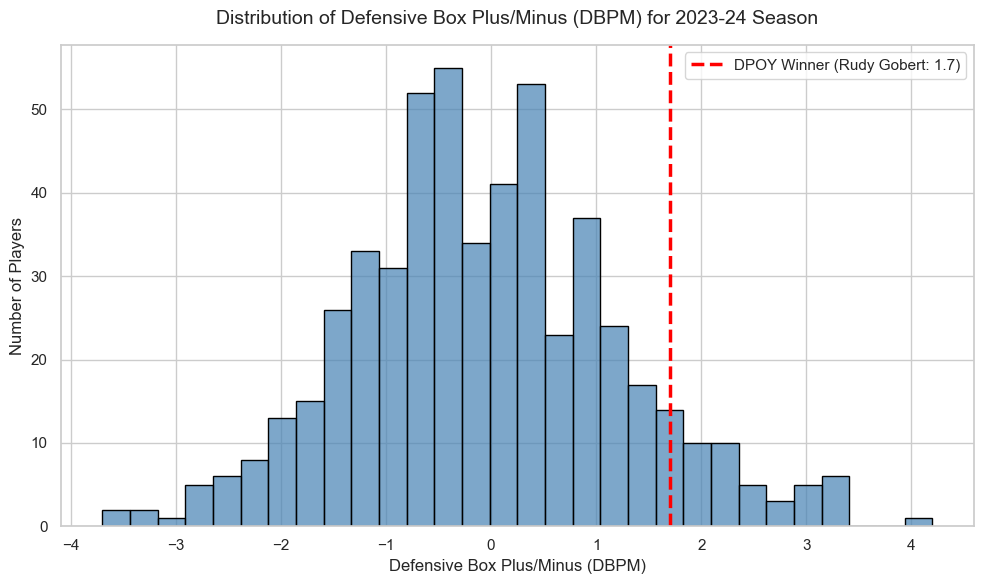

In [3]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load fully wrangled data from data/02-processed
df_winners = pd.read_csv('data/02-processed/dpoy_winners_cleaned.csv')
df_stats = pd.read_csv('data/02-processed/nba_player_stats_cleaned.csv')

# Re-apply the DPOY Winner label for the 2023-24 season
df_stats['is_DPOY_Winner'] = 0
season_winner = df_winners[df_winners['Season'] == '2023-24']['Player'].values[0]
df_stats.loc[df_stats['Player'] == season_winner, 'is_DPOY_Winner'] = 1

# Filter out low-minute players to remove noise (e.g., < 20 games)
df_filtered = df_stats[df_stats['G'] >= 20].copy()

# Create a theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Visualize with histogram
sns.histplot(data=df_filtered, x='DBPM', bins=30, color='steelblue', edgecolor='black', alpha=0.7)

# Highlight the DPOY Winner with a vertical line
winner_dbpm = df_filtered[df_filtered['is_DPOY_Winner'] == 1]['DBPM'].values[0]
plt.axvline(x=winner_dbpm, color='red', linestyle='--', linewidth=2.5,
            label=f'DPOY Winner ({season_winner}: {winner_dbpm})')

# Add titles and labels
plt.title('Distribution of Defensive Box Plus/Minus (DBPM) for 2023-24 Season', fontsize=14, pad=15)
plt.xlabel('Defensive Box Plus/Minus (DBPM)', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

#### Section 2: Traditional Stats vs. Advanced Metrics

**Breakdown:** It is easy to assume that a player who gets a lot of blocks is automatically an elite defender, but blocks only capture one visible part of defense and can sometimes reflect role or opportunity rather than overall impact. To test how well a traditional box-score stat aligns with broader defensive value, we compare Blocks Per Game to Defensive Win Shares (DWS), an advanced metric intended to estimate how much a player contributes to team wins through defense. If blocks alone were a complete measure of defense, we would expect a tight, almost linear relationship. Using a scatter plot helps us see whether high-block players consistently also rate highly by DWS, and whether the DPOY winner stands out when considering both metrics together.

**Interpretation:**
The scatter plot shows a general positive relationship between blocks and DWS, but the pattern is clearly not perfectly linear. Many players cluster at low-to-moderate block rates with a wide range of DWS values, which suggests that defensive impact depends on more than rim protection alone. We also see players with solid block numbers but relatively low DWS, indicating that blocks may not always translate to overall team defensive success. In contrast, the DPOY winner appears in the upper-right region of the plot, meaning they combine strong shot-blocking with high overall defensive contribution as measured by DWS. This supports including both traditional stats and advanced metrics in our model, since advanced metrics appear to capture defensive value that raw block totals can miss.

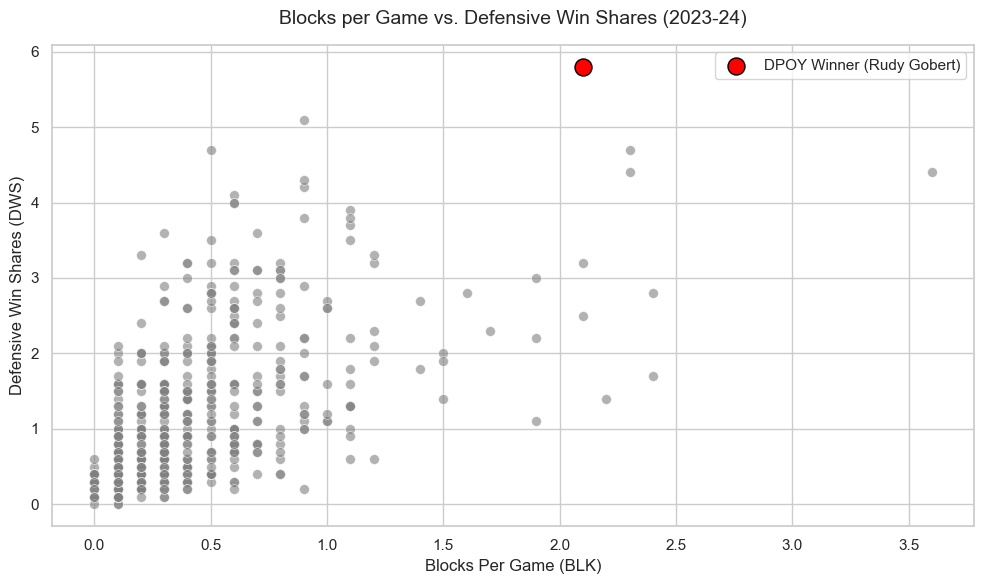

In [4]:
# Section 2: Scatter Plot of Blocks vs. Defensive Win Shares
plt.figure(figsize=(10, 6))

# Create the scatter plot
sns.scatterplot(data=df_filtered, x='BLK', y='DWS', color='gray', alpha=0.6, s=50)

# Highlight the DPOY Winner
winner_data = df_filtered[df_filtered['is_DPOY_Winner'] == 1]
plt.scatter(winner_data['BLK'], winner_data['DWS'], color='red', s=150, edgecolor='black',
            label=f"DPOY Winner ({winner_data['Player'].values[0]})", zorder=5)

# Add titles and labels
plt.title('Blocks per Game vs. Defensive Win Shares (2023-24)', fontsize=14, pad=15)
plt.xlabel('Blocks Per Game (BLK)', fontsize=12)
plt.ylabel('Defensive Win Shares (DWS)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

#### Section 3: The Workload Threshold (Availability as a Skill)

**Breakdown:**
In our project proposal, we established an eligibility threshold because DPOY winners almost always combine elite defensive impact with high availability. Advanced defensive metrics can become misleading when a player has limited minutes or appears in only a small number of games, since small samples can inflate per-possession impact measures and do not reflect season-long contribution. To visualize the “realistic candidate pool,” we plot Games Played (G) versus Minutes Per Game (MP) and highlight both the DPOY winner and a 65-game threshold. This helps us see whether DPOY winners tend to come from the high-workload region of the league and whether a workload filter is justified before modeling.

**Interpretation:**
The plot shows that the highest-availability players cluster toward the right side (more games), while the highest-minute contributors appear toward the top (starter-level minutes). The DPOY winner sits in the extreme top-right region, indicating they played most games and logged heavy minutes, consistent with how voters typically reward defenders who anchor a team’s defense across the full season. This supports treating availability as a key predictor and/or a candidate-pool constraint, since low-game or low-minute players are unlikely to win regardless of efficiency. As a result, we will include workload variables like games played and minutes per game in our model and consider stricter thresholds during modeling to reduce noise and reflect real DPOY voting behavior.

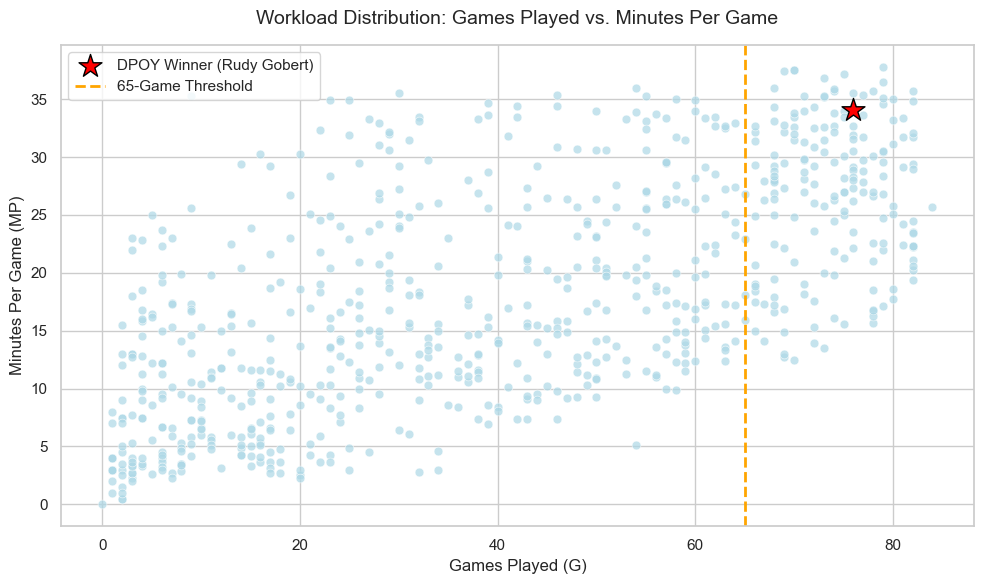

In [5]:
# Section 3: Scatter Plot of Workload (Games vs Minutes)
plt.figure(figsize=(10, 6))

# Create the scatter plot
sns.scatterplot(data=df_stats, x='G', y='MP', color='lightblue', alpha=0.7, s=40)

# Highlight the DPOY Winner
plt.scatter(winner_data['G'], winner_data['MP'], color='red', marker='*', s=300, edgecolor='black',
            label=f"DPOY Winner ({winner_data['Player'].values[0]})", zorder=5)

# Add a dashed line representing the 65-game minimum threshold
plt.axvline(x=65, color='orange', linestyle='--', linewidth=2, label='65-Game Threshold')

# Add titles and labels
plt.title('Workload Distribution: Games Played vs. Minutes Per Game', fontsize=14, pad=15)
plt.xlabel('Games Played (G)', fontsize=12)
plt.ylabel('Minutes Per Game (MP)', fontsize=12)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

# ETC AD NASEUM?

From the instructions, and I quote:
"Some more words and stuff." Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

## Ethics

Instructions: Keep the contents of this cell. For each item on the checklist
-  put an X there if you've considered the item
-  IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.

Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section.  You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.

Here is a [list of real world examples](https://deon.drivendata.org/examples/) for each item in the checklist that can refer to.

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> Example of how to use the checkbox, and also of how you can put in a short paragraph that discusses the way this checklist item affects your project.  Remove this paragraph and the X in the checkbox before you fill this out for your project

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> Because our label is the DPOY winner, the dataset reflects media voting behavior and narrative, not purely defensive ability. This can introduce bias toward high visibility players, players on winning teams, and certain defensive archetypes (for example rim protecting bigs). We will acknowledge that we are predicting award outcomes and include team context and workload controls to reduce misattribution.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> Our data consists of publicly available player names and season level performance statistics, so we are not handling sensitive personal identifiers. We will avoid adding any unnecessary personal information and will keep the analysis focused on performance variables relevant to the research question.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

> Our project uses publicly available basketball statistics and award outcome data rather than private or personally identifying information. Because of this, the security risk is relatively low. Still, we store the project data in our team repository with access limited to team members and course staff through GitHub permissions, and we avoid modifying raw source files directly so the processing pipeline remains transparent and reproducible.

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

> This project does not use personal user data collected from individuals, so there is no realistic “right to be forgotten” request process needed in this case. The data comes from public sports records that are already published as part of professional league reporting. If a source dataset were removed or corrected by the publisher, we would update our project accordingly rather than continuing to rely on outdated records.

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

> Because the dataset is small, public, and course-related, we will retain it only for the duration of the project and any short period needed for grading or reproducibility. After the course ends, there is no need to maintain a long-term stored copy beyond the submitted project materials. Since the data is public and non-sensitive, retention does not create major privacy concerns, but we still do not plan to preserve unnecessary duplicate copies.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

> Public box score and advanced summary stats do not capture many important defensive contributions such as communication, scheme responsibility, and off ball deterrence. To address this blindspot, we will interpret results cautiously and frame conclusions as patterns in historical award selection rather than definitive statements about true defensive value.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> The data will be highly imbalanced because only one player per season wins DPOY, and many players are clear non candidates. We will mitigate this by defining a reasonable candidate pool using availability and minutes thresholds and by evaluating with ranking style metrics such as whether the true winner appears in the top k predictions, rather than relying only on accuracy. We will also discuss omitted variable bias since many defensive actions are not recorded in the available data.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> We will ensure plots and summaries accurately reflect the data by using clear labels, consistent scales, and transparent reporting of any filtering rules such as minimum games played or minutes. We will avoid cherry picking seasons or examples and will report both successes and failure cases to prevent misleading conclusions.

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> We will document all data extraction and cleaning steps, keep code and outputs organized, and ensure the full workflow is reproducible. This includes saving intermediate datasets, using consistent file paths, and making it possible to rerun the notebook from start to finish to verify results.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

> Even without protected attribute variables, our model could rely on proxies that systematically favor certain groups of players, such as position correlated statistics like blocks or rebounding that tend to advantage centers. We will examine feature importance and error patterns across position or role categories and discuss how historical voting preferences may influence the model.

 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

> While we are not evaluating fairness across protected demographic groups, we can still test whether the model behaves differently across basketball relevant groups such as bigs versus wings or guards. If prediction errors are consistently higher for certain roles, we will report this and interpret it as either a limitation of the available features or a reflection of how the award has historically been given.

 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

> Because the goal is to identify the winner among many candidates, we will not rely on a single evaluation metric. We will use ranking and retrieval style metrics such as top k accuracy and compare multiple models to ensure conclusions are not driven by one metric choice.

 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
> We will prioritize interpretable modeling approaches and provide understandable explanations for which variables drive predictions. We will use model coefficients or feature importance and include example comparisons between predicted top candidates and the actual winner to make the reasoning transparent.

 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

> We will clearly state that our model predicts historical DPOY outcomes based on publicly available statistics and that it cannot fully capture defense due to measurement limitations and unobserved actions. We will include a limitations section that explains potential bias from voting narratives, team context, and role, and we will avoid claiming that the model measures true defensive ability.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

> Although this project is for an academic setting and not deployed, sports prediction outputs can still be misinterpreted as definitive rankings or used to influence narratives. We will reduce this risk by emphasizing uncertainty, reporting limitations, and framing results as probabilistic predictions of award outcomes rather than judgments about individual players.

# Discussion and Conclusion

Wrap it all up here. Somewhere between 3 and 10 paragraphs roughly.

1. Summarize the important results you made
2. This is a good time to refer back to your Background section and review how this work extended the previous stuff.
3. Try to bring all the different results together into a bigger picture... what have we learned?
4. Often what we learned is confusing. Discuss if there are contradictory results how that might have happened
5. Discuss the limitations of your work. e.g, is the dataset a biased sample? would more data make you more confident? would longitudinal instead of cross-sectional data helpful? is there evidence that the phenomena you're investigating may change over time? etc
6. If you would like, you can also say what the next steps in this investigation might be if the work was to continue outside this class

Our project investigated whether publicly available season-level defensive statistics and team context can be used to identify or predict the NBA Defensive Player of the Year. Overall, our results suggest that these features do capture meaningful patterns associated with DPOY-level performance, but they do not reduce the award to any single statistic. Across our analyses, the strongest candidates tended to stand out through a combination of advanced defensive metrics, traditional counting stats, and sustained availability over the course of the season. This supports our original hypothesis that DPOY voting reflects a broader defensive profile rather than one isolated measure of performance.

One of the clearest findings from our exploratory analysis was that the eventual winner consistently appeared among the strongest defenders in the dataset when using advanced metrics such as Defensive Box Plus/Minus. This suggests that publicly available advanced statistics do capture part of the signal that separates elite defenders from the rest of the league. At the same time, the winner was not always completely isolated from other top players, which is also important. Several players may post elite defensive metrics in the same season, meaning that while these numbers are useful for narrowing the field of realistic candidates, they are not enough by themselves to fully explain the final award outcome.

Our comparison of blocks per game and Defensive Win Shares reinforced this point. There was a positive relationship between these measures, but not a perfect one, showing that traditional box-score statistics only capture one dimension of defensive value. Blocks are one of the most visible and intuitive defensive stats, especially for big men, but they do not account for all of the ways a player can impact defense. A player may protect the rim, deter shots, switch effectively, communicate within a scheme, or elevate overall team defense without recording especially high block totals. Because of this, the strongest DPOY cases appear to be built not just on visible defensive events, but on broader indicators of two-way impact and season-long contribution.

Our workload analysis added another useful layer to the overall picture. We expected games played and minutes played to matter because DPOY is a full-season award, and our results supported that expectation. The winner appeared not only as an elite defender in terms of efficiency and value metrics, but also as a player who sustained that impact across a large share of the season. This suggests that availability should not be viewed as a minor detail, but as part of the defensive résumé itself. Even a highly impactful defender may be less competitive in award voting if that impact is not maintained over enough games and minutes to shape a full season narrative.

Taken together, these results point to a broader conclusion: DPOY recognition appears to come from the intersection of performance, consistency, and context. Strong candidates tend to combine elite advanced defensive metrics, credible traditional defensive production, and enough playing time to make their impact meaningful over an entire season. This bigger-picture view is important because it helps explain why simple one-variable approaches are often unsatisfying. Defense is inherently multidimensional, and the award process seems to reflect that complexity even when based on imperfect public statistics.

These findings also connect back to the ideas discussed in the background section. Prior basketball analytics work often emphasizes that defense is more difficult to quantify than offense because many important defensive actions do not appear directly in the box score. Our project supports that idea while also showing that public data still contains meaningful structure. In other words, we may not be measuring “true defense” in a complete sense, but we are capturing a statistical profile that aligns with how elite defenders are recognized in practice. That is a useful contribution, because it shows that even imperfect defensive metrics can still help explain award-level outcomes when interpreted together rather than in isolation.

At the same time, our results should be interpreted with caution because there are several important limitations in this project. First, the target outcome itself is based on voting, which introduces subjectivity. DPOY is not purely a measurement of defensive talent; it is also shaped by media narratives, team success, visibility, reputation, and voter preferences. Second, the dataset is inherently limited and imbalanced, since there is only one winner per season. That makes prediction difficult and means that broad conclusions should be made carefully. Third, many valuable defensive qualities are still missing from standard public statistics, including communication, rotational discipline, matchup difficulty, deterrence, and scheme versatility. As a result, our analysis is better understood as a study of patterns associated with DPOY selection rather than a perfect model of defensive ability itself.

There are also structural limitations related to basketball context more generally. Different eras of the NBA emphasize different defensive roles, and the meaning of specific statistics may shift over time as pace, spacing, and player responsibilities change. In addition, some metrics may naturally favor certain archetypes, especially rim-protecting centers, while undervaluing perimeter defenders whose impact is harder to summarize numerically. This means that even strong models may reflect biases in the data rather than a complete and position-neutral picture of defense. That is especially relevant for an award like DPOY, where certain player types may historically receive more recognition than others.

If this investigation were continued beyond the class, there are several promising next steps. Expanding the dataset across more seasons would improve the reliability of the analysis and allow stronger comparisons across eras. Additional team-level context, such as overall defensive rating, lineup effects, or team success, could help explain why some elite defenders receive more recognition than others. Incorporating player-tracking or matchup data would also strengthen the project by capturing forms of defensive impact that box-score and derived metrics miss. Finally, it would be useful to evaluate not just whether a model identifies the winner, but whether it can consistently rank the top group of realistic candidates in a given season.

Overall, our project shows that publicly available defensive metrics do provide meaningful information about who becomes a serious DPOY candidate, but they are best viewed as complementary pieces of evidence rather than definitive answers. The most important lesson from this analysis is that elite defensive recognition emerges from multiple interacting factors: statistical impact, consistency across the season, and the broader context in which that defense occurs. In that sense, our findings both support the usefulness of defensive analytics and highlight their limits. We learned that data can meaningfully inform conversations about defensive excellence, but also that defense remains one of the most difficult aspects of basketball to fully capture with numbers alone.

## Team Expectations 

* **Team Expectation 1 (Communication and meetings):** We communicate primarily through Discord and use text messaging only for urgent issues close to deadlines. Each team member is expected to respond within 24 hours on weekdays and within 36 hours on weekends. We hold a scheduled weekly check-in meeting, either virtual or in person depending on availability, and add a short extra meeting during checkpoint weeks when needed.

* **Team Expectation 2 (Tone and collaboration norms):** We use a direct but respectful tone and rely on “I” statements when giving feedback, such as, “I think this section is unclear because…”. We assume critiques are well intentioned and focus feedback on improving the work rather than criticizing individuals. During meetings, we make sure everyone has space to speak and actively invite quieter members to share their input.

* **Team Expectation 3 (Decision making process):** We aim for consensus on most decisions after discussing evidence and tradeoffs. If we cannot reach consensus within a reasonable amount of time, we use a majority vote. When a quick decision is needed and a team member is unresponsive, the assigned lead for that section may make the decision after notifying the group, and we revisit it later if concerns arise.

* **Team Expectation 4 (Task assignment and tracking):** We divide work by section ownership, such as data curation, wrangling, EDA, modeling, and writing, while rotating support tasks to keep the workload balanced. We track tasks and deadlines through GitHub Issues so that everyone can see what is assigned, what is in progress, and what is complete. For each checkpoint, at least one other team member reviews the code and writing for clarity, correctness, and alignment with the rubric.

* **Team Expectation 5 (Deadlines and reliability):** We set internal deadlines 24 to 48 hours before official due dates to allow time for debugging, editing, and integration. Each team member is responsible for completing assigned tasks by the internal deadline and communicating early about any anticipated delays. Before any submission, we use “Restart and Run All” in the notebook(s) to confirm that the project runs without errors.

* **Team Expectation 6 (If someone is struggling or falls behind):** If a member is struggling to complete an assigned task, they will inform the team as soon as possible rather than
waiting until the deadline. The team will re scope the task, redistribute work, or pair program to recover. If a member repeatedly misses commitments without communication, we will
document the issue in writing and set specific improvement expectations; if there is no improvement, we will escalate to course staff following course guidance.

* **Team Expectation 7 (Conflict resolution):** If conflict arises, we first discuss the issue privately as a team, focusing on the specific problem and identifying a concrete solution. When needed, we use a facilitator during meetings to keep the conversation productive and ensure equal participation. If the conflict cannot be resolved internally, we contact course staff early for guidance rather than allowing the issue to persist.

## Project Timeline Proposal

We do not anticipate needing special resources or training beyond what is covered in COGS 108. We will use Python tools such as pandas, numpy, and matplotlib or seaborn, along with standard modeling approaches like logistic regression and tree based models. We will collect public NBA player and team statistics from Basketball Reference and will document all data extraction and cleaning steps to ensure reproducibility.


| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 1/20  |  1 PM | Read and think about COGS 108 expectations; brainstorm project ideas; agree on initial scope for predicting NBA DPOY  | Decide communication method and meeting schedule; confirm final topic and project scope; outline variables and controls; assign initial roles for background, data sourcing, and writing |
| 1/26  |  10 AM |  Do background research using Basketball Reference; draft research question and hypothesis; review DPOY history page for labeling approach | Refine research question and hypothesis; discuss validity threats and limitations; outline ethics concerns; draft background section with citations |
| 2/1  | 10 AM  | Edit, finalize, and submit proposal; confirm datasets on Basketball Reference; identify key tables needed for player stats, advanced stats, and team defense  | Discuss wrangling plan and file organization; assign group members to lead data extraction, cleaning, and EDA; confirm candidate pool rules and minimum games played threshold   |
| 2/14  | 6 PM  | Import and wrangle data into a merged player season dataset; create DPOY winner labels; begin initial EDA plots | Review and validate wrangling; address missingness and outliers; finalize feature list; confirm modeling plan and evaluation metrics   |
| 2/23  | 12 PM  | Finalize wrangling and EDA; begin modeling with baseline models; implement season based train test split | Review baseline results; refine features and candidate pool; decide final models to compare; plan interpretability outputs such as coefficients or feature importance |
| 3/13  | 12 PM  | Complete modeling and error analysis; draft results, conclusion, and discussion; prepare final figures and tables| Discuss and edit full project draft; ensure claims match results; finalize ethics and limitations; run restart and run all to verify notebooks run end to end |
| 3/18  | Before 11:59 PM  | NA | Turn in final project and group project surveys; verify GitHub shows latest notebooks and required sections are complete |